In [1]:
%cd /content/drive/MyDrive/zepto-capstone/analytics

print("Current folder:")
!pwd

[Errno 2] No such file or directory: '/content/drive/MyDrive/zepto-capstone/analytics'
/content
Current folder:
/content


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/zepto-capstone/analytics

print("Current folder:")
!pwd

/content/drive/MyDrive/zepto-capstone/analytics
Current folder:
/content/drive/MyDrive/zepto-capstone/analytics


In [4]:
!ls -la

total 128
drwx------ 4 root root  4096 Sep 27 05:24 .
drwx------ 6 root root  4096 Sep 27 05:24 ..
drwx------ 2 root root  4096 Sep 27 10:24 charts
drwx------ 2 root root  4096 Sep 27 10:24 model
-rw------- 1 root root     0 Sep 27 05:25 README.md
-rw------- 1 root root 56519 Sep 27 12:11 titanic_cleaned.csv
-rw------- 1 root root 57018 Sep 27 12:06 titanic.csv


In [5]:
import pandas as pd
import numpy as np

# Load the cleaned dataset created in 01_eda.ipynb
df = pd.read_csv("titanic_cleaned.csv")

print("Cleaned Titanic dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Cleaned Titanic dataset loaded successfully.
Shape: (889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [6]:
features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]
y = df["survived"]

print("Features:")
print(features)

print("\nTarget:", y.name)

print("\nClass distribution:")
print(y.value_counts())

print("\nClass distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target: survived

Class distribution:
survived
0    549
1    340
Name: count, dtype: int64

Class distribution (%):
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training samples: 711
Testing samples: 178

Training class distribution:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Testing class distribution:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric and categorical columns
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [9]:
# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data without fitting again
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (711, 10)
Testing processed shape: (178, 10)


In [10]:
preprocessor.fit_transform(X_train)

array([[-1.60146146,  0.96794127,  0.46976084, ...,  0.        ,
         0.        ,  1.        ],
       [-0.39143054, -0.10787086, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [-1.60146146, -0.10787086, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.81860038,  1.42900361,  0.46976084, ...,  0.        ,
         0.        ,  1.        ],
       [-1.60146146,  1.35215988, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [-1.60146146, -0.10787086, -0.46844129, ...,  0.        ,
         0.        ,  1.        ]])

In [11]:
preprocessor.transform(X_test)

array([[ 0.81860038,  1.12162871, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.81860038, -0.10787086, -0.46844129, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.81860038, -0.10787086, -0.46844129, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.39143054, -0.10787086, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [-1.60146146, -1.02999554, -0.46844129, ...,  0.        ,
         0.        ,  1.        ],
       [-0.39143054,  0.12266031,  0.46976084, ...,  0.        ,
         0.        ,  1.        ]])

In [12]:
preprocessor.fit_transform(X_test)

array([[ 0.8527193 ,  1.17238561, -0.50466538, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.8527193 , -0.07493097, -0.50466538, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.8527193 , -0.07493097, -0.50466538, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.30593746, -0.07493097, -0.50466538, ...,  0.        ,
         0.        ,  1.        ],
       [-1.46459422, -1.0104184 , -0.50466538, ...,  0.        ,
         0.        ,  1.        ],
       [-0.30593746,  0.15894089,  0.30461784, ...,  0.        ,
         0.        ,  1.        ]])

In [13]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nProcessed feature names:")
print(feature_names)

Number of processed features: 10

Processed feature names:
['numeric__pclass' 'numeric__age' 'numeric__sibsp' 'numeric__parch'
 'numeric__fare' 'categorical__sex_female' 'categorical__sex_male'
 'categorical__embarked_C' 'categorical__embarked_Q'
 'categorical__embarked_S']


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# MODEL 1 — LOGISTIC REGRESSION
# ==========================================

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)


# ==========================================
# MODEL 2 — DECISION TREE
# ==========================================

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

tree_pipeline.fit(X_train, y_train)


# ==========================================
# MODEL 3 — RANDOM FOREST
# ==========================================

forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

forest_pipeline.fit(X_train, y_train)


print("All three models trained successfully.")

All three models trained successfully.


In [15]:
# Predictions
y_pred_logistic = logistic_pipeline.predict(X_test)
y_pred_tree = tree_pipeline.predict(X_test)
y_pred_forest = forest_pipeline.predict(X_test)

# Prediction probabilities for ROC/AUC
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]
y_prob_forest = forest_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [16]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Confusion Matrix": cm
    }


results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_logistic,
        y_prob_logistic
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree,
        y_prob_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_forest,
        y_prob_forest
    )
)

results_df = pd.DataFrame(results)

display(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "AUC"
        ]
    ].round(4)
)

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.809,0.7656,0.7206,0.7424,0.8196


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_data = [
    ("Logistic Regression", y_pred_logistic),
    ("Decision Tree", y_pred_tree),
    ("Random Forest", y_pred_forest)
]

for ax, (name, predictions) in zip(axes, model_data):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

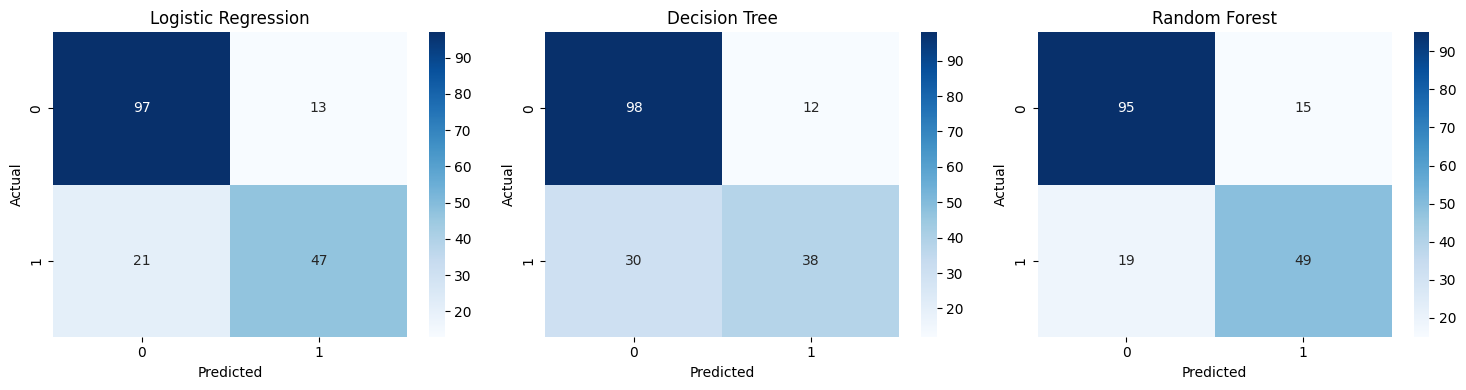

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_data = [
    ("Logistic Regression", y_pred_logistic),
    ("Decision Tree", y_pred_tree),
    ("Random Forest", y_pred_forest)
]

for ax, (name, predictions) in zip(axes, model_data):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

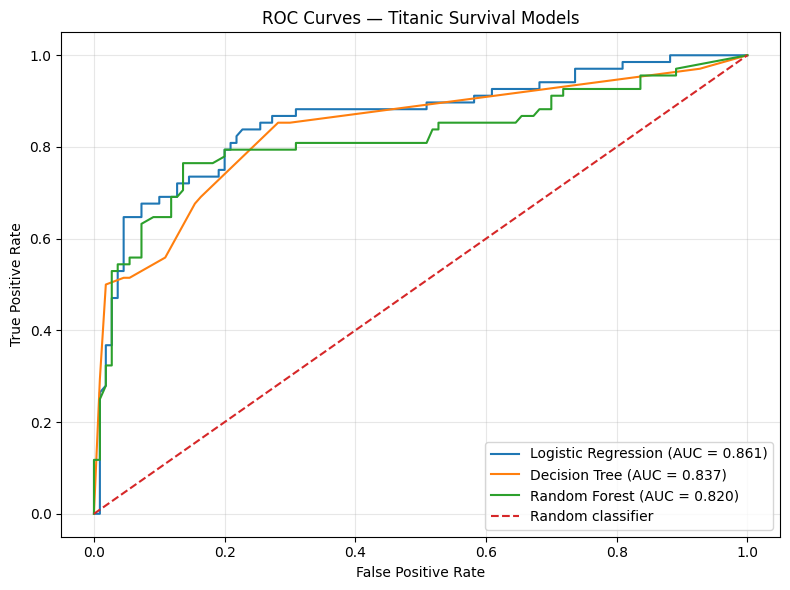

AUC Scores
Logistic Regression: 0.861
Decision Tree: 0.8374
Random Forest: 0.8196


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_forest)

# Calculate AUC
auc_log = roc_auc_score(y_test, y_prob_logistic)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_rf = roc_auc_score(y_test, y_prob_forest)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log, tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_tree, tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Titanic Survival Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("AUC Scores")
print("Logistic Regression:", round(auc_log, 4))
print("Decision Tree:", round(auc_tree, 4))
print("Random Forest:", round(auc_rf, 4))

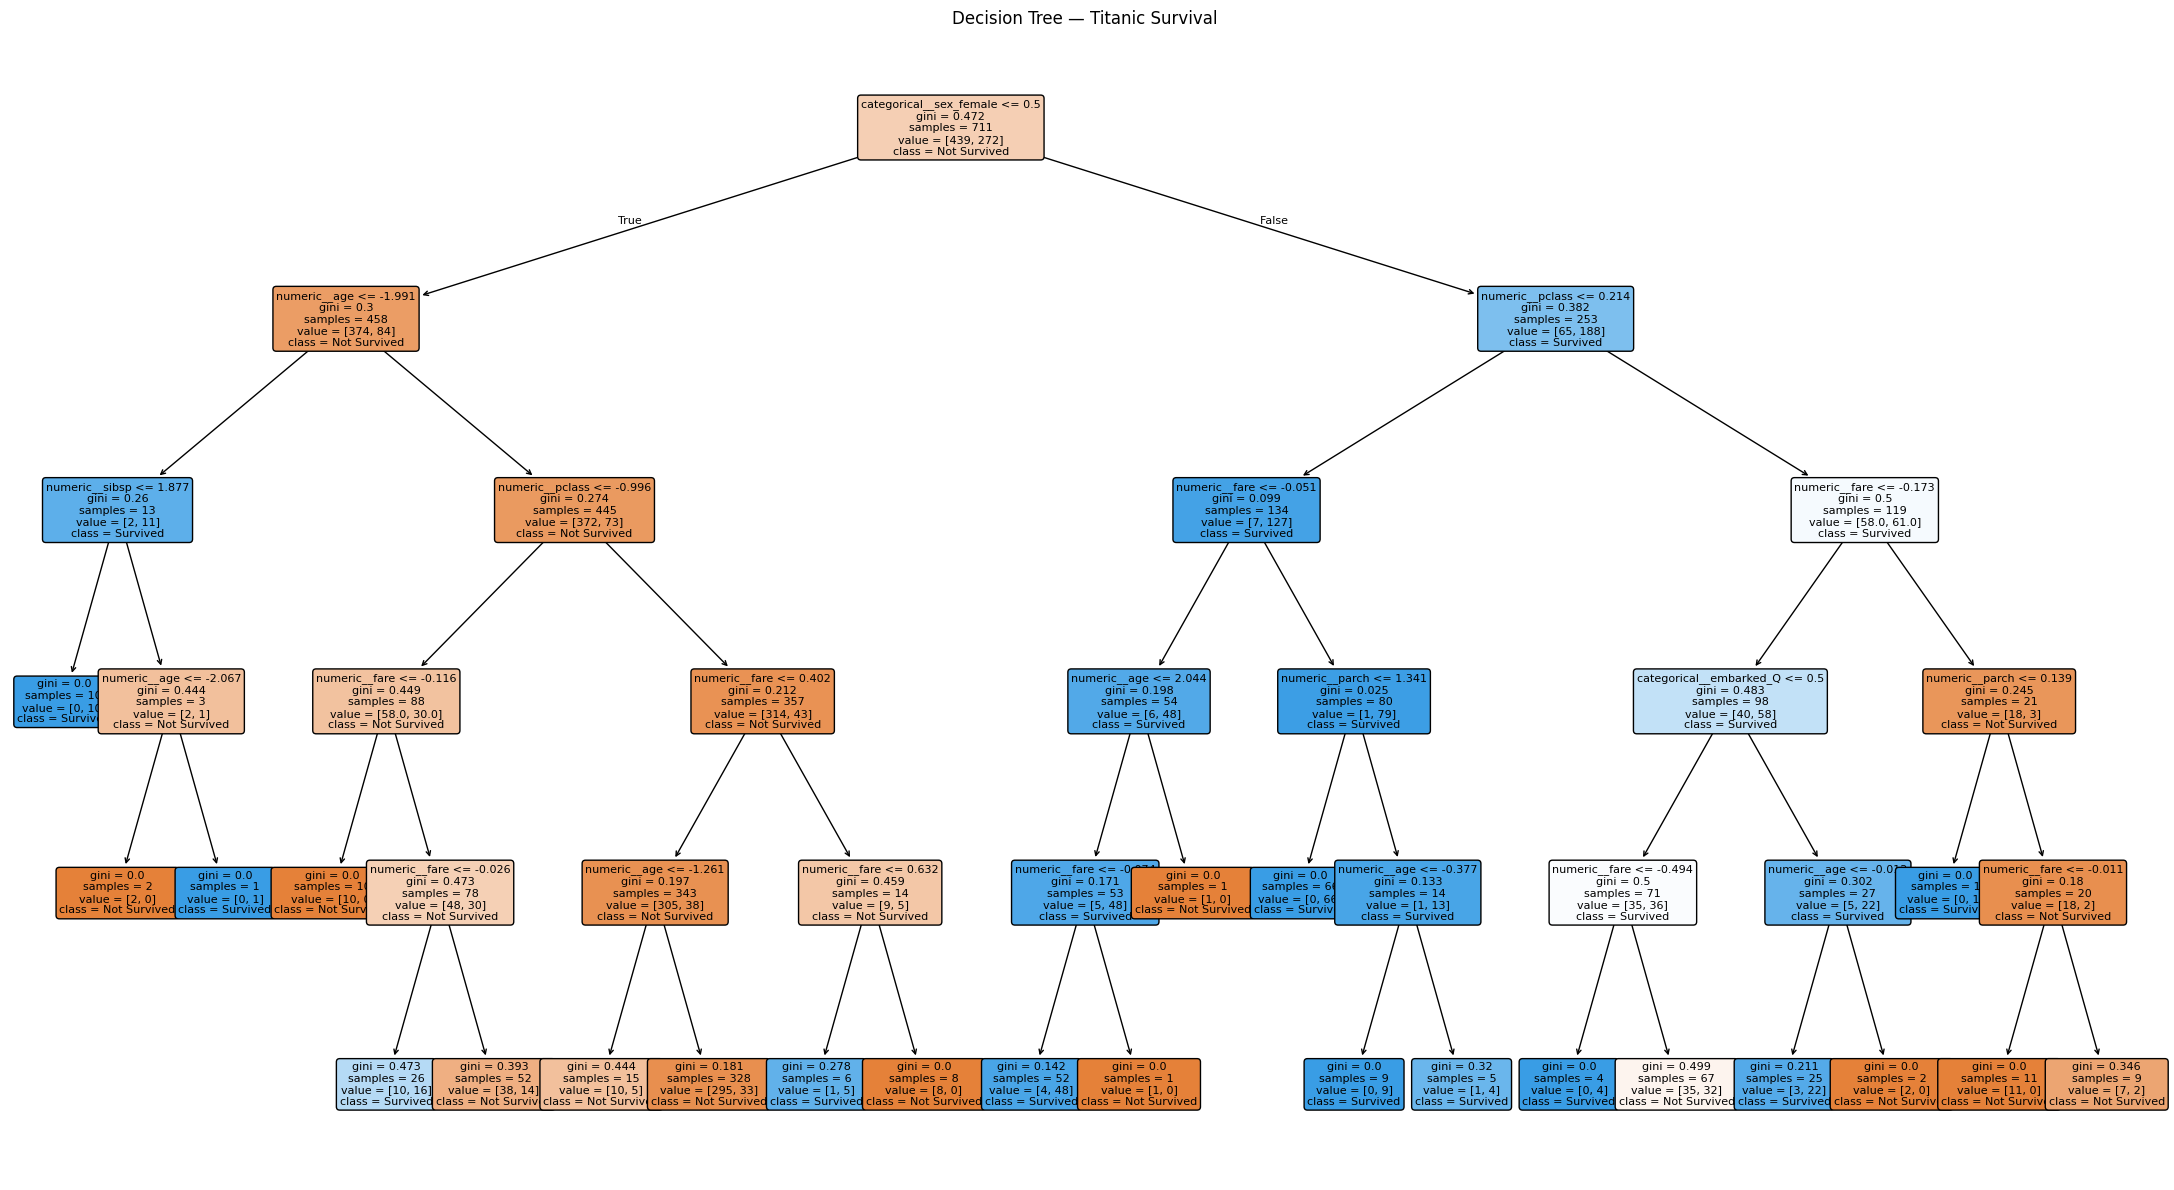

In [20]:
from sklearn.tree import plot_tree

# Get the fitted Decision Tree from the pipeline
tree_model = tree_pipeline.named_steps["model"]

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree — Titanic Survival")
plt.tight_layout()
plt.show()

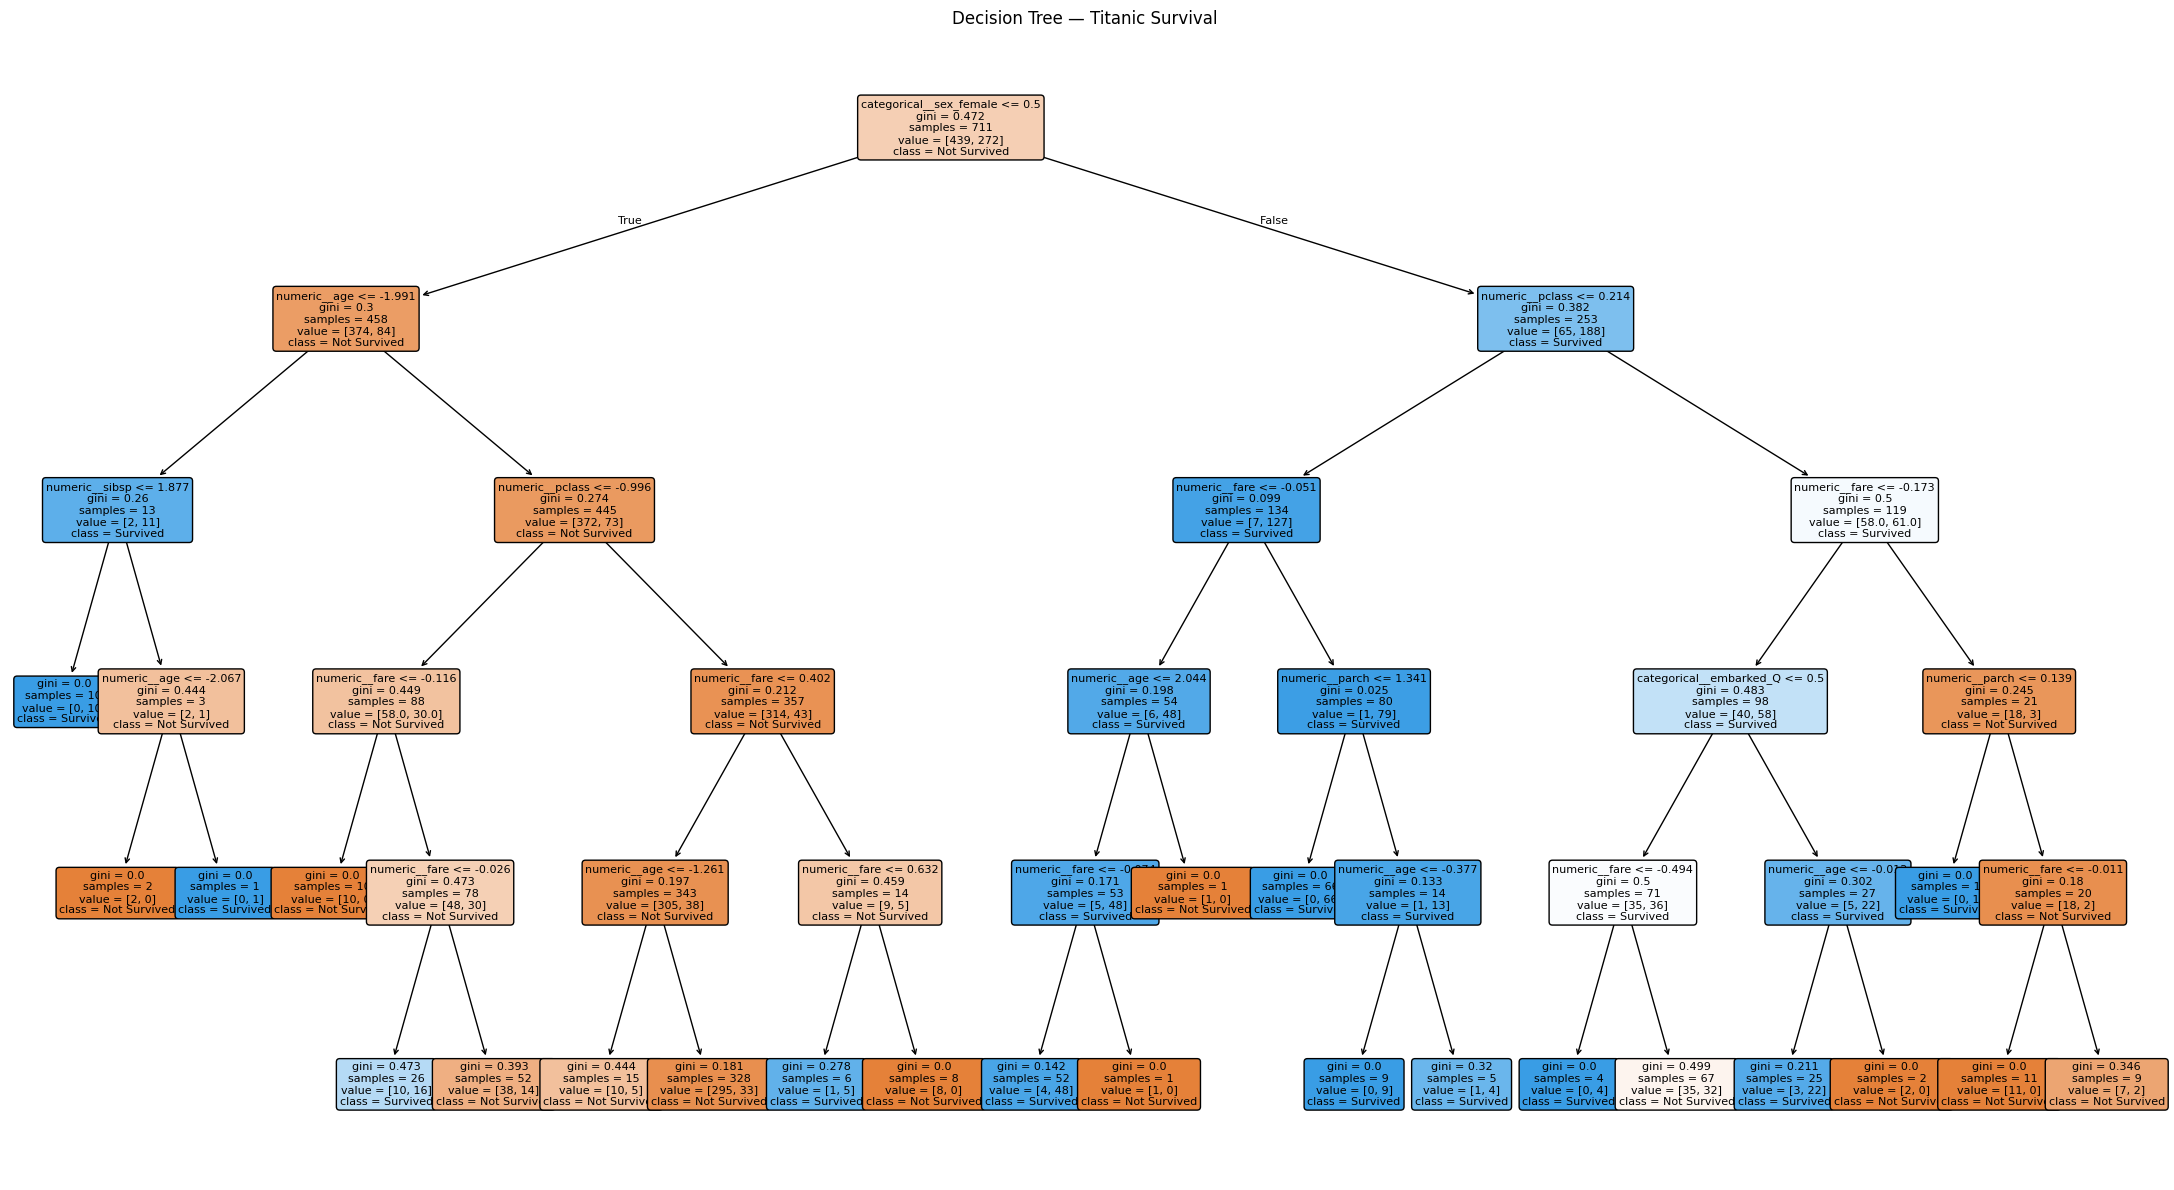

Decision tree saved to model/decision_tree.png


In [21]:
plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree — Titanic Survival")
plt.tight_layout()

plt.savefig(
    "model/decision_tree.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Decision tree saved to model/decision_tree.png")

In [22]:
!pip install -q imbalanced-learn

In [23]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

# ==========================================
# IMBALANCE COMPARISON
# ==========================================

# ------------------------------------------
# A. BASELINE
# ------------------------------------------

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)


# ------------------------------------------
# B. CLASS WEIGHT = BALANCED
# ------------------------------------------

balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)


# ------------------------------------------
# C. SMOTE
# ------------------------------------------

# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training class distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


# Train logistic regression on SMOTE data
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)


# ------------------------------------------
# COMPARE RESULTS
# ------------------------------------------

imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(y_test, baseline_pred),
        "Recall": recall_score(y_test, baseline_pred),
        "F1": f1_score(y_test, baseline_pred)
    },
    {
        "Strategy": "Class Weight Balanced",
        "Precision": precision_score(y_test, balanced_pred),
        "Recall": recall_score(y_test, balanced_pred),
        "F1": f1_score(y_test, balanced_pred)
    },
    {
        "Strategy": "SMOTE",
        "Precision": precision_score(y_test, smote_pred),
        "Recall": recall_score(y_test, smote_pred),
        "F1": f1_score(y_test, smote_pred)
    }
])

print("\n===== IMBALANCE COMPARISON =====")

display(
    imbalance_results.round(4)
)

_IncompleteInputError: incomplete input (3107874910.py, line 106)

In [24]:
# ==========================================
# COMPARE IMBALANCE STRATEGIES
# ==========================================

imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(y_test, baseline_pred),
        "Recall": recall_score(y_test, baseline_pred),
        "F1": f1_score(y_test, baseline_pred)
    },
    {
        "Strategy": "Class Weight Balanced",
        "Precision": precision_score(y_test, balanced_pred),
        "Recall": recall_score(y_test, balanced_pred),
        "F1": f1_score(y_test, balanced_pred)
    },
    {
        "Strategy": "SMOTE",
        "Precision": precision_score(y_test, smote_pred),
        "Recall": recall_score(y_test, smote_pred),
        "F1": f1_score(y_test, smote_pred)
    }
])

print("===== IMBALANCE COMPARISON =====")

display(
    imbalance_results.round(4)
)

NameError: name 'baseline_pred' is not defined

In [25]:
# ==========================================
# TASK 11 — IMBALANCE HANDLING COMPARISON
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# ------------------------------------------
# 1. BASELINE — NO IMBALANCE HANDLING
# ------------------------------------------

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)


# ------------------------------------------
# 2. CLASS WEIGHT = BALANCED
# ------------------------------------------

balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)


# ------------------------------------------
# 3. SMOTE
# ------------------------------------------

# Fit preprocessing ONLY on training data
smote_preprocessor = preprocessor

X_train_processed = smote_preprocessor.fit_transform(X_train)
X_test_processed = smote_preprocessor.transform(X_test)

# Apply SMOTE ONLY to training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("===== CLASS DISTRIBUTION =====")

print("\nOriginal training data:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


# Train model using SMOTE training data
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test_processed)


# ------------------------------------------
# 4. CALCULATE METRICS
# ------------------------------------------

imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(y_test, baseline_pred),
        "Recall": recall_score(y_test, baseline_pred),
        "F1": f1_score(y_test, baseline_pred)
    },
    {
        "Strategy": "Class Weight Balanced",
        "Precision": precision_score(y_test, balanced_pred),
        "Recall": recall_score(y_test, balanced_pred),
        "F1": f1_score(y_test, balanced_pred)
    },
    {
        "Strategy": "SMOTE",
        "Precision": precision_score(y_test, smote_pred),
        "Recall": recall_score(y_test, smote_pred),
        "F1": f1_score(y_test, smote_pred)
    }
])

print("\n===== IMBALANCE COMPARISON =====")

display(
    imbalance_results.round(4)
)

===== CLASS DISTRIBUTION =====

Original training data:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

===== IMBALANCE COMPARISON =====


,Strategy,Precision,Recall,F1
0,Baseline,0.7833,0.6912,0.7344
1,Class Weight Balanced,0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353


### Imbalance Handling Comparison

The baseline model achieved the highest precision (0.7833), while the class-weight-balanced model achieved the highest recall (0.7500). SMOTE produced the highest F1 score (0.7353) among the three tested strategies, with balanced precision and recall of 0.7353 each. Therefore, based on F1 as a balance between precision and recall, SMOTE performed best in this comparison, although the differences in F1 were small.

In [26]:
imbalance_results.to_csv(
    "model/imbalance_comparison.csv",
    index=False
)

print("Imbalance comparison saved.")

Imbalance comparison saved.


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# ==========================================
# RANDOM FOREST GRID SEARCH
# ==========================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

print("Grid search completed.")

print("\n===== BEST PARAMETERS =====")
print(grid_search.best_params_)

print("\n===== BEST CROSS-VALIDATION F1 =====")
print(round(grid_search.best_score_, 4))

# Best fitted pipeline
best_rf_pipeline = grid_search.best_estimator_

# Extract fitted Random Forest
best_rf_model = best_rf_pipeline.named_steps["model"]

print("\n===== OOB SCORE =====")
print(round(best_rf_model.oob_score_, 4))

Grid search completed.

===== BEST PARAMETERS =====
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

===== BEST CROSS-VALIDATION F1 =====
0.7408

===== OOB SCORE =====
0.8214


In [28]:
tuning_results = pd.DataFrame({
    "best_n_estimators": [grid_search.best_params_["model__n_estimators"]],
    "best_max_depth": [grid_search.best_params_["model__max_depth"]],
    "best_max_features": [grid_search.best_params_["model__max_features"]],
    "best_cv_f1": [grid_search.best_score_],
    "oob_score": [best_rf_model.oob_score_]
})

display(tuning_results.round(4))

tuning_results.to_csv(
    "model/random_forest_tuning.csv",
    index=False
)

print("Random Forest tuning results saved.")

,best_n_estimators,best_max_depth,best_max_features,best_cv_f1,oob_score
0,200,5,sqrt,0.7408,0.8214


Random Forest tuning results saved.


In [29]:
# ==========================================
# TUNED RANDOM FOREST TEST EVALUATION
# ==========================================

y_pred_tuned_rf = best_rf_pipeline.predict(X_test)
y_prob_tuned_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)
tuned_rf_precision = precision_score(y_test, y_pred_tuned_rf)
tuned_rf_recall = recall_score(y_test, y_pred_tuned_rf)
tuned_rf_f1 = f1_score(y_test, y_pred_tuned_rf)
tuned_rf_auc = roc_auc_score(y_test, y_prob_tuned_rf)

print("===== TUNED RANDOM FOREST TEST RESULTS =====")
print("Accuracy :", round(tuned_rf_accuracy, 4))
print("Precision:", round(tuned_rf_precision, 4))
print("Recall   :", round(tuned_rf_recall, 4))
print("F1       :", round(tuned_rf_f1, 4))
print("AUC      :", round(tuned_rf_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rf))

===== TUNED RANDOM FOREST TEST RESULTS =====
Accuracy : 0.8315
Precision: 0.8654
Recall   : 0.6618
F1       : 0.75
AUC      : 0.8389

Confusion Matrix:
[[103   7]
 [ 23  45]]


In [30]:
# ==========================================
# FARE REGRESSION
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

# Predictors
regression_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "sex",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]

print("Regression features:")
print(regression_features)

print("\nTarget: fare")
print("Rows:", len(y_reg))

Regression features:
['pclass', 'age', 'sibsp', 'parch', 'sex', 'embarked']

Target: fare
Rows: 889


In [31]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training samples:", len(X_reg_train))
print("Regression testing samples:", len(X_reg_test))

Regression training samples: 711
Regression testing samples: 178


In [32]:
reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    (
        "numeric",
        reg_numeric_pipeline,
        reg_numeric_features
    ),
    (
        "categorical",
        reg_categorical_pipeline,
        reg_categorical_features
    )
])

regression_pipeline = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

print("Regression pipeline trained successfully.")

Regression pipeline trained successfully.


In [33]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_reg_pred = regression_pipeline.predict(X_reg_test)

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)

r2 = r2_score(
    y_reg_test,
    y_reg_pred
)

# Number of observations
n = len(y_reg_test)

# Number of predictors after preprocessing
X_reg_test_processed = regression_pipeline.named_steps[
    "preprocessor"
].transform(X_reg_test)

p = X_reg_test_processed.shape[1]

# Adjusted R-squared
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("===== FARE REGRESSION RESULTS =====")
print("MAE         :", round(mae, 4))
print("RMSE        :", round(rmse, 4))
print("R²          :", round(r2, 4))
print("Adjusted R² :", round(adjusted_r2, 4))

print("\nNumber of observations:", n)
print("Number of model features:", p)

===== FARE REGRESSION RESULTS =====
MAE         : 21.1386
RMSE        : 41.7465
R²          : 0.3468
Adjusted R² : 0.3118

Number of observations: 178
Number of model features: 9


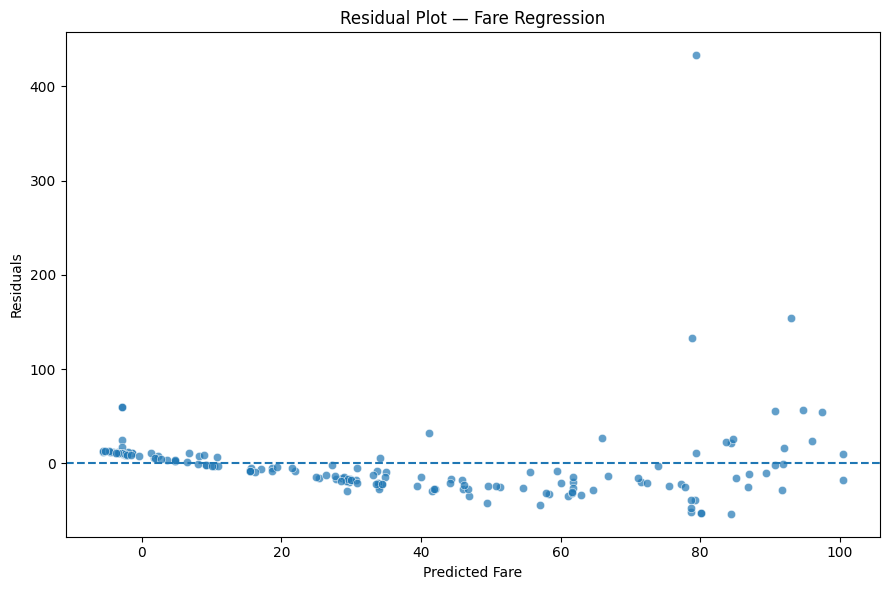

Residual plot saved to model/fare_regression_residuals.png


In [34]:
# ==========================================
# RESIDUAL ANALYSIS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals
residuals = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=y_reg_pred,
    y=residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Fare Regression")

plt.tight_layout()

plt.savefig(
    "model/fare_regression_residuals.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Residual plot saved to model/fare_regression_residuals.png")

In [35]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Add constant for the test
bp_X = sm.add_constant(y_reg_pred)

bp_test = het_breuschpagan(
    residuals,
    bp_X
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = dict(zip(bp_labels, bp_test))

print("===== BREUSCH-PAGAN TEST =====")

for key, value in bp_results.items():
    print(f"{key}: {value:.6f}")

===== BREUSCH-PAGAN TEST =====
LM Statistic: 4.183738
LM p-value: 0.040814
F Statistic: 4.236300
F p-value: 0.041042


In [36]:
regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Adjusted R2"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})

display(regression_results.round(4))

regression_results.to_csv(
    "model/fare_regression_results.csv",
    index=False
)

print("Regression results saved.")

,Metric,Value
0,MAE,21.1386
1,RMSE,41.7465
2,R2,0.3468
3,Adjusted R2,0.3118


Regression results saved.


### Residual Analysis and Heteroscedasticity

The residual plot shows that the spread of residuals changes across the range of predicted fare values, rather than remaining constant. The Breusch-Pagan test produced an LM p-value of 0.0408 and an F-test p-value of 0.0410. Since both p-values are below 0.05, there is statistical evidence of heteroscedasticity in the regression residuals.

In [37]:
# ==========================================
# FINAL CLASSIFICATION MODEL COMPARISON
# ==========================================

final_classification_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1": f1_score(y_test, y_pred_logistic),
        "AUC": roc_auc_score(y_test, y_prob_logistic)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, y_pred_tree),
        "Precision": precision_score(y_test, y_pred_tree),
        "Recall": recall_score(y_test, y_pred_tree),
        "F1": f1_score(y_test, y_pred_tree),
        "AUC": roc_auc_score(y_test, y_prob_tree)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_forest),
        "Precision": precision_score(y_test, y_pred_forest),
        "Recall": recall_score(y_test, y_pred_forest),
        "F1": f1_score(y_test, y_pred_forest),
        "AUC": roc_auc_score(y_test, y_prob_forest)
    },
    {
        "Model": "Tuned Random Forest",
        "Accuracy": tuned_rf_accuracy,
        "Precision": tuned_rf_precision,
        "Recall": tuned_rf_recall,
        "F1": tuned_rf_f1,
        "AUC": tuned_rf_auc
    }
])

display(final_classification_results.round(4))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.8090,0.7656,0.7206,0.7424,0.8196
3,Tuned Random Forest,0.8315,0.8654,0.6618,0.7500,0.8389


In [38]:
final_classification_results.to_csv(
    "model/classification_model_comparison.csv",
    index=False
)

print("Classification comparison saved.")

Classification comparison saved.


In [39]:
import joblib

joblib.dump(
    best_rf_pipeline,
    "model/titanic_random_forest_pipeline.joblib"
)

print("Complete Random Forest pipeline saved.")

Complete Random Forest pipeline saved.


In [40]:
# ==========================================
# JOBLIB RELOAD TEST
# ==========================================

loaded_pipeline = joblib.load(
    "model/titanic_random_forest_pipeline.joblib"
)

reload_predictions = loaded_pipeline.predict(
    X_test.head(5)
)

print("Reloaded pipeline successfully.")
print("\nPredictions from reloaded pipeline:")
print(reload_predictions)

print("\nActual values:")
print(y_test.head(5).values)

print("\nReload test completed successfully.")

Reloaded pipeline successfully.

Predictions from reloaded pipeline:
[0 0 0 0 0]

Actual values:
[0 0 0 0 0]

Reload test completed successfully.


In [41]:
!ls -lh model/

total 1.5M
-rw------- 1 root root  438 Sep 27 13:30 classification_model_comparison.csv
-rw------- 1 root root 590K Sep 27 12:51 decision_tree.png
-rw------- 1 root root  52K Sep 27 13:27 fare_regression_residuals.png
-rw------- 1 root root  113 Sep 27 13:28 fare_regression_results.csv
-rw------- 1 root root  213 Sep 27 13:00 imbalance_comparison.csv
-rw------- 1 root root  121 Sep 27 13:04 random_forest_tuning.csv
-rw------- 1 root root 825K Sep 27 13:31 titanic_random_forest_pipeline.joblib


In [42]:
import os

notebook_path = "/content/drive/MyDrive/zepto-capstone/analytics/02_modeling.ipynb"

if os.path.exists(notebook_path):
    print("✅ 02_modeling.ipynb EXISTS")
    print("Path:")
    print(notebook_path)
else:
    print("❌ 02_modeling.ipynb NOT FOUND")

❌ 02_modeling.ipynb NOT FOUND


In [43]:
import os

notebook_path = "/content/drive/MyDrive/zepto-capstone/analytics/02_modeling.ipynb"

if os.path.exists(notebook_path):
    print("✅ 02_modeling.ipynb EXISTS")
    print("Correct location:")
    print(notebook_path)
else:
    print("❌ NOT FOUND")

✅ 02_modeling.ipynb EXISTS
Correct location:
/content/drive/MyDrive/zepto-capstone/analytics/02_modeling.ipynb


In [44]:
%cd /content/drive/MyDrive/zepto-capstone

!git status

/content/drive/MyDrive/zepto-capstone
Refresh index: 100% (18/18), done.
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	analytics/01_eda.ipynb
	analytics/02_modeling.ipynb
	analytics/charts/
	analytics/model/
	analytics/titanic.csv
	analytics/titanic_cleaned.csv

nothing added to commit but untracked files present (use "git add" to track)


In [45]:
!git add analytics

In [46]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   analytics/01_eda.ipynb
	new file:   analytics/02_modeling.ipynb
	new file:   analytics/charts/age_by_survival.png
	new file:   analytics/charts/age_fare_survival.png
	new file:   analytics/charts/fare_by_survival.png
	new file:   analytics/charts/survival_by_sex_class.png
	new file:   analytics/model/classification_model_comparison.csv
	new file:   analytics/model/decision_tree.png
	new file:   analytics/model/fare_regression_residuals.png
	new file:   analytics/model/fare_regression_results.csv
	new file:   analytics/model/imbalance_comparison.csv
	new file:   analytics/model/random_forest_tuning.csv
	new file:   analytics/model/titanic_random_forest_pipeline.joblib
	new file:   analytics/titanic.csv
	new file:   analytics/titanic_cleaned.csv

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
 